<a href="https://colab.research.google.com/github/Muchee-ai/California-housing-test/blob/main/California_housing_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("sample_data/california_housing_test.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [4]:
df.shape

(3000, 9)

In [5]:

df.info

<bound method DataFrame.info of       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0       -122.05     37.37                27.0       3885.0           661.0   
1       -118.30     34.26                43.0       1510.0           310.0   
2       -117.81     33.78                27.0       3589.0           507.0   
3       -118.36     33.82                28.0         67.0            15.0   
4       -119.67     36.33                19.0       1241.0           244.0   
...         ...       ...                 ...          ...             ...   
2995    -119.86     34.42                23.0       1450.0           642.0   
2996    -118.14     34.06                27.0       5257.0          1082.0   
2997    -119.70     36.30                10.0        956.0           201.0   
2998    -117.12     34.10                40.0         96.0            14.0   
2999    -119.63     34.42                42.0       1765.0           263.0   

      population  households  median_income  median_house_value  
0         1537.0       606.0         6.6085            344700.0  
1          809.0       277.0         3.5990            176500.0  
2         1484.0       495.0         5.7934            270500.0  
3           49.0        11.0         6.1359            330000.0  
4          850.0       237.0         2.9375             81700.0  
...          ...         ...            ...                 ...  
2995      1258.0       607.0         1.1790            225000.0  
2996      3496.0      1036.0         3.3906            237200.0  
2997       693.0       220.0         2.2895             62000.0  
2998        46.0        14.0         3.2708            162500.0  
2999       753.0       260.0         8.5608            500001.0  

[3000 rows x 9 columns]>

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


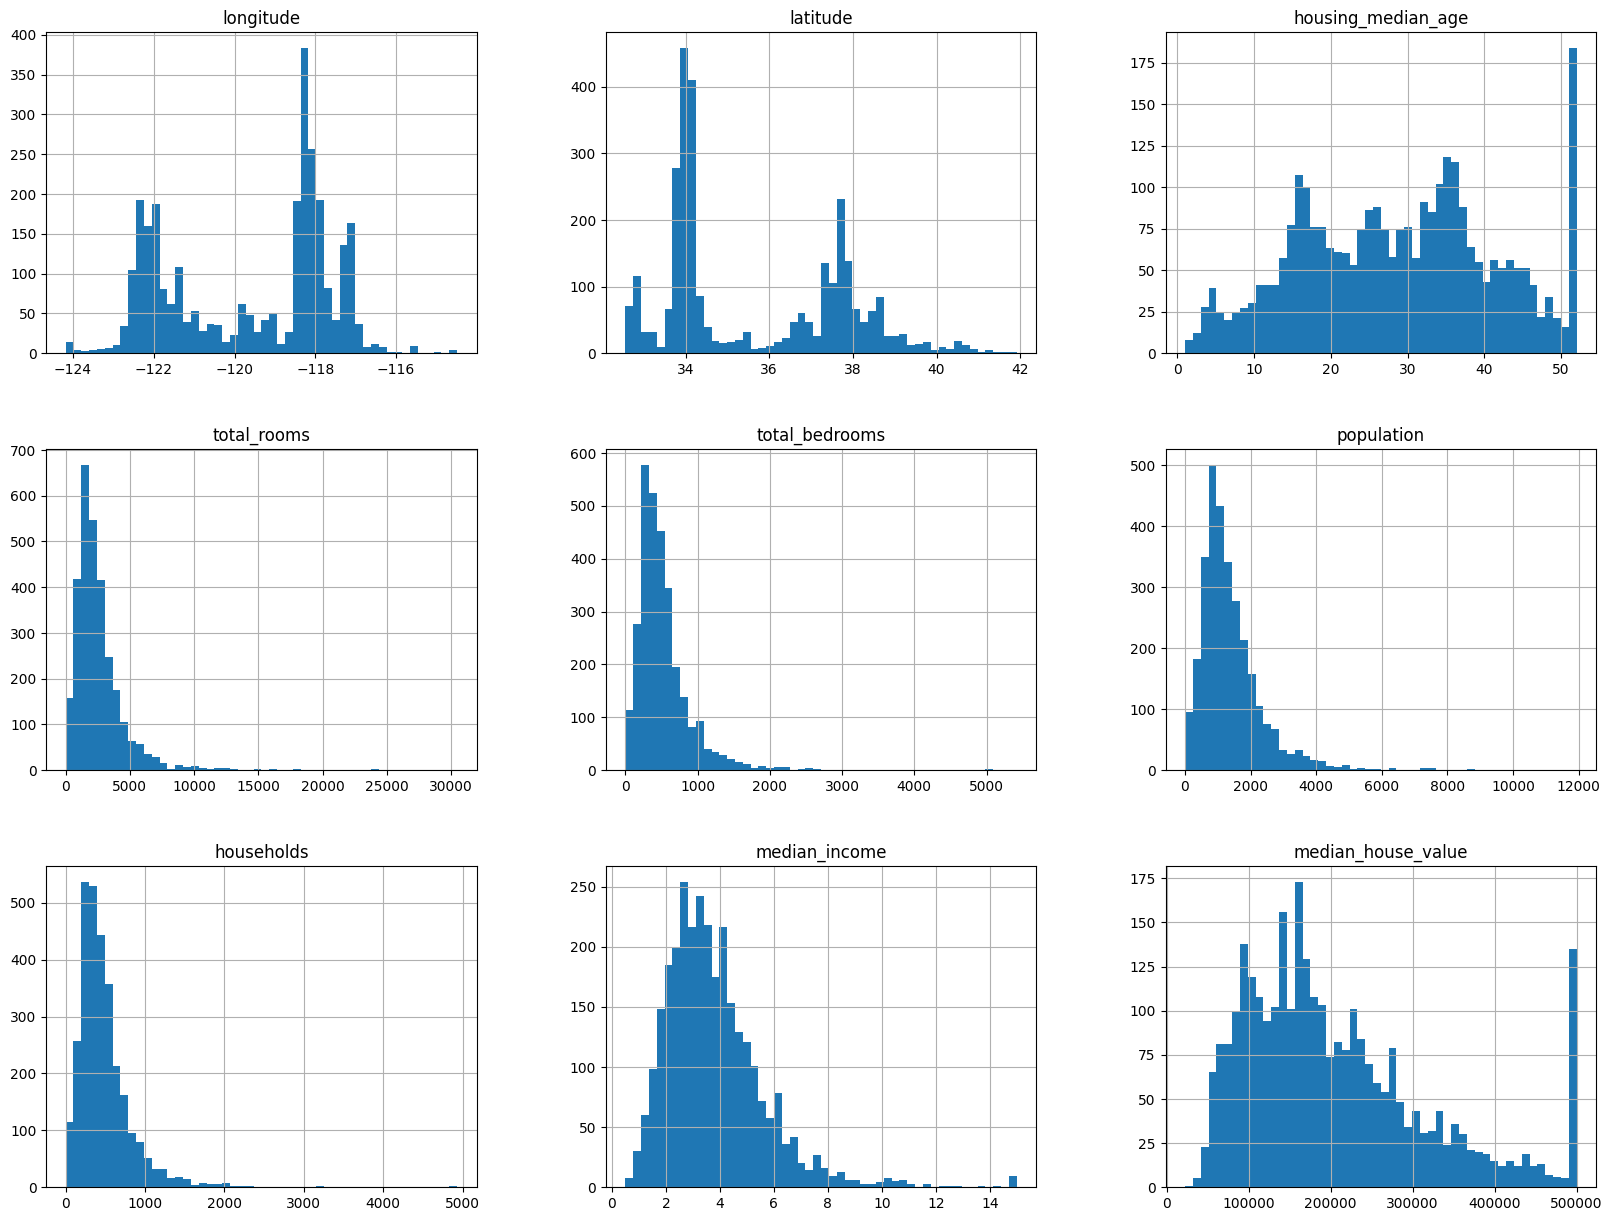

In [7]:
%matplotlib inline
df.hist(bins=50, figsize=(20,15))
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=35)

In [9]:
train_set.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1760,-118.43,34.17,33.0,1679.0,404.0,933.0,412.0,2.6979,266000.0
1723,-122.00,36.97,30.0,1029.0,242.0,753.0,249.0,3.1205,240500.0
1745,-122.04,36.98,35.0,2155.0,355.0,866.0,335.0,5.6188,404700.0
1338,-122.70,39.14,13.0,532.0,111.0,214.0,62.0,3.3929,108300.0
401,-118.52,34.16,39.0,2693.0,478.0,1219.0,435.0,5.1700,335400.0
1402,-121.66,39.66,17.0,3502.0,655.0,1763.0,613.0,2.9625,101200.0
2052,-117.95,33.76,24.0,3956.0,812.0,3196.0,795.0,4.3512,191400.0
914,-122.70,38.33,16.0,1244.0,242.0,696.0,236.0,3.6369,158700.0
672,-117.14,32.90,16.0,3217.0,716.0,2054.0,687.0,4.2234,162100.0
1564,-117.69,34.01,30.0,2598.0,573.0,2170.0,518.0,2.3000,95600.0


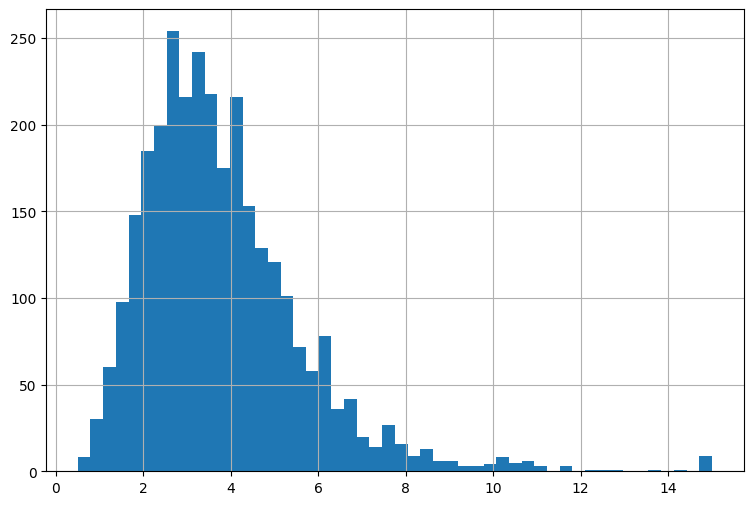

In [14]:
%matplotlib inline
df['median_income'].hist(bins=50, figsize=(9,6))
plt.show()

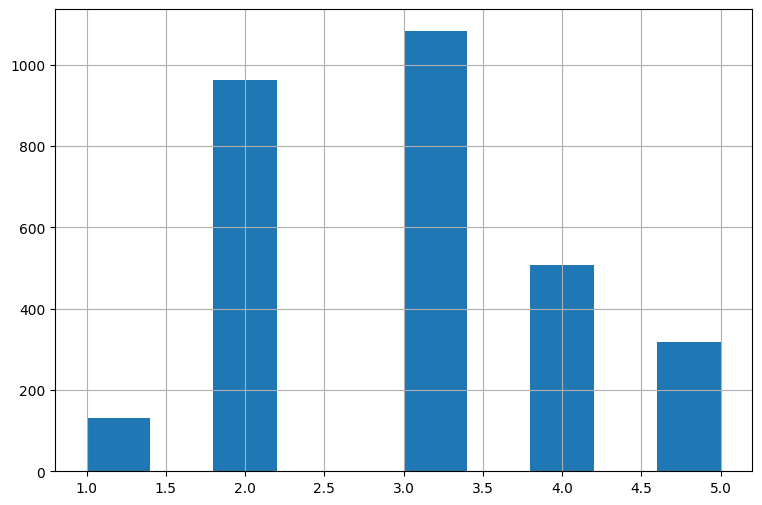

In [16]:
df['income_cat'] = pd.cut(df['median_income'], bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])
df['income_cat'].hist(figsize=(9,6))
plt.show()

In [17]:
df.sample(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
1167,-120.66,35.26,15.0,5540.0,1319.0,2383.0,1165.0,2.2656,226200.0,2
231,-122.58,38.46,15.0,2936.0,517.0,1182.0,501.0,3.3981,246900.0,3
139,-122.04,37.36,26.0,3298.0,460.0,1241.0,472.0,6.8753,403000.0,5
1651,-118.24,34.14,27.0,2909.0,1021.0,2614.0,935.0,2.1444,229000.0,2
2028,-121.12,38.86,17.0,3949.0,717.0,1683.0,686.0,3.3802,216500.0,3


In [20]:
from re import split
from sklearn.model_selection import StratifiedShuffleSplit
stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in stratified_split.split(df,df['income_cat']):
  strat_train_set = df.loc[train_index]
  strat_train_set = df.loc[test_index]


In [21]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat
280,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,5
785,-120.35,37.04,37.0,1495.0,292.0,858.0,275.0,2.9306,46300.0,2
2387,-117.30,34.05,6.0,2155.0,544.0,1039.0,391.0,1.6675,95800.0,2
2526,-118.08,33.77,26.0,2461.0,562.0,971.0,544.0,2.1944,87500.0,2
2341,-120.35,39.34,29.0,1986.0,474.0,337.0,100.0,4.0278,95800.0,3
...,...,...,...,...,...,...,...,...,...,...
1912,-118.51,34.26,29.0,2472.0,354.0,1109.0,397.0,5.5433,332500.0,4
307,-121.88,37.37,14.0,6016.0,1404.0,3258.0,1316.0,3.5745,333700.0,3
1900,-119.95,36.96,18.0,1996.0,379.0,1327.0,356.0,2.6087,96000.0,2
689,-117.70,33.68,29.0,5650.0,1084.0,3985.0,1056.0,2.8192,162500.0,2


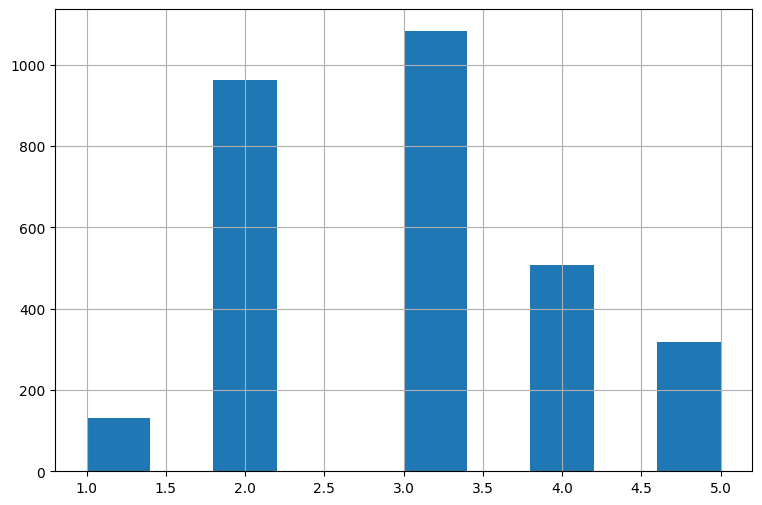

In [22]:
df['income_cat'].hist(figsize=(9,6))
plt.show()

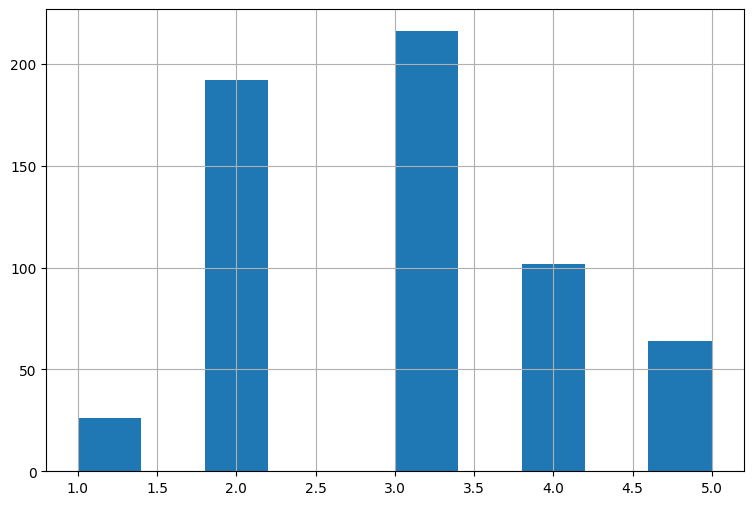

In [23]:
strat_train_set['income_cat'].hist(figsize=(9,6))
plt.show()

In [26]:
#strat_train_set.drop("income_cat", axis=1, inplace=True)
#strat_test_set.drop("income_cat", axis=1, inplace=True)


In [27]:
housing = strat_train_set.copy()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
280,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0
785,-120.35,37.04,37.0,1495.0,292.0,858.0,275.0,2.9306,46300.0
2387,-117.30,34.05,6.0,2155.0,544.0,1039.0,391.0,1.6675,95800.0
2526,-118.08,33.77,26.0,2461.0,562.0,971.0,544.0,2.1944,87500.0
2341,-120.35,39.34,29.0,1986.0,474.0,337.0,100.0,4.0278,95800.0


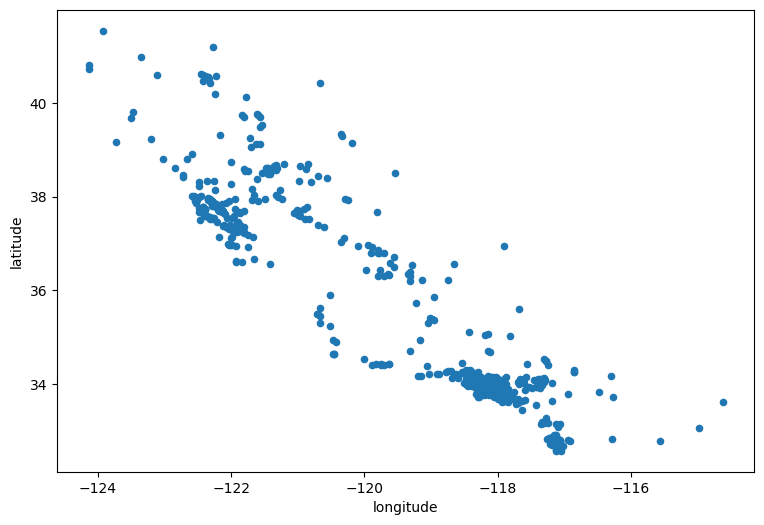

In [28]:
housing.plot(kind='scatter', x='longitude', y='latitude', figsize=(9,6))
plt.show()

In [30]:
#housing.plot(
    #kind="scatter",
    #x = "longitude",
    #y = "latitude",
    #alpha = 0.4,
    #s=housing['population']/50,
    #label=['population'],
    #c='median_housing_value',
    #cmap="jet",
    #colorbar=True,
    #figsize=(10,8)
#)
#plt.show()

In [31]:
housing.corrwith(housing['median_house_value']).sort_values(ascending=False)

,0
median_house_value,1.000000
median_income,0.671468
total_rooms,0.186604
households,0.108957
housing_median_age,0.100255
total_bedrooms,0.089968
population,0.015768
longitude,-0.031104
latitude,-0.153184


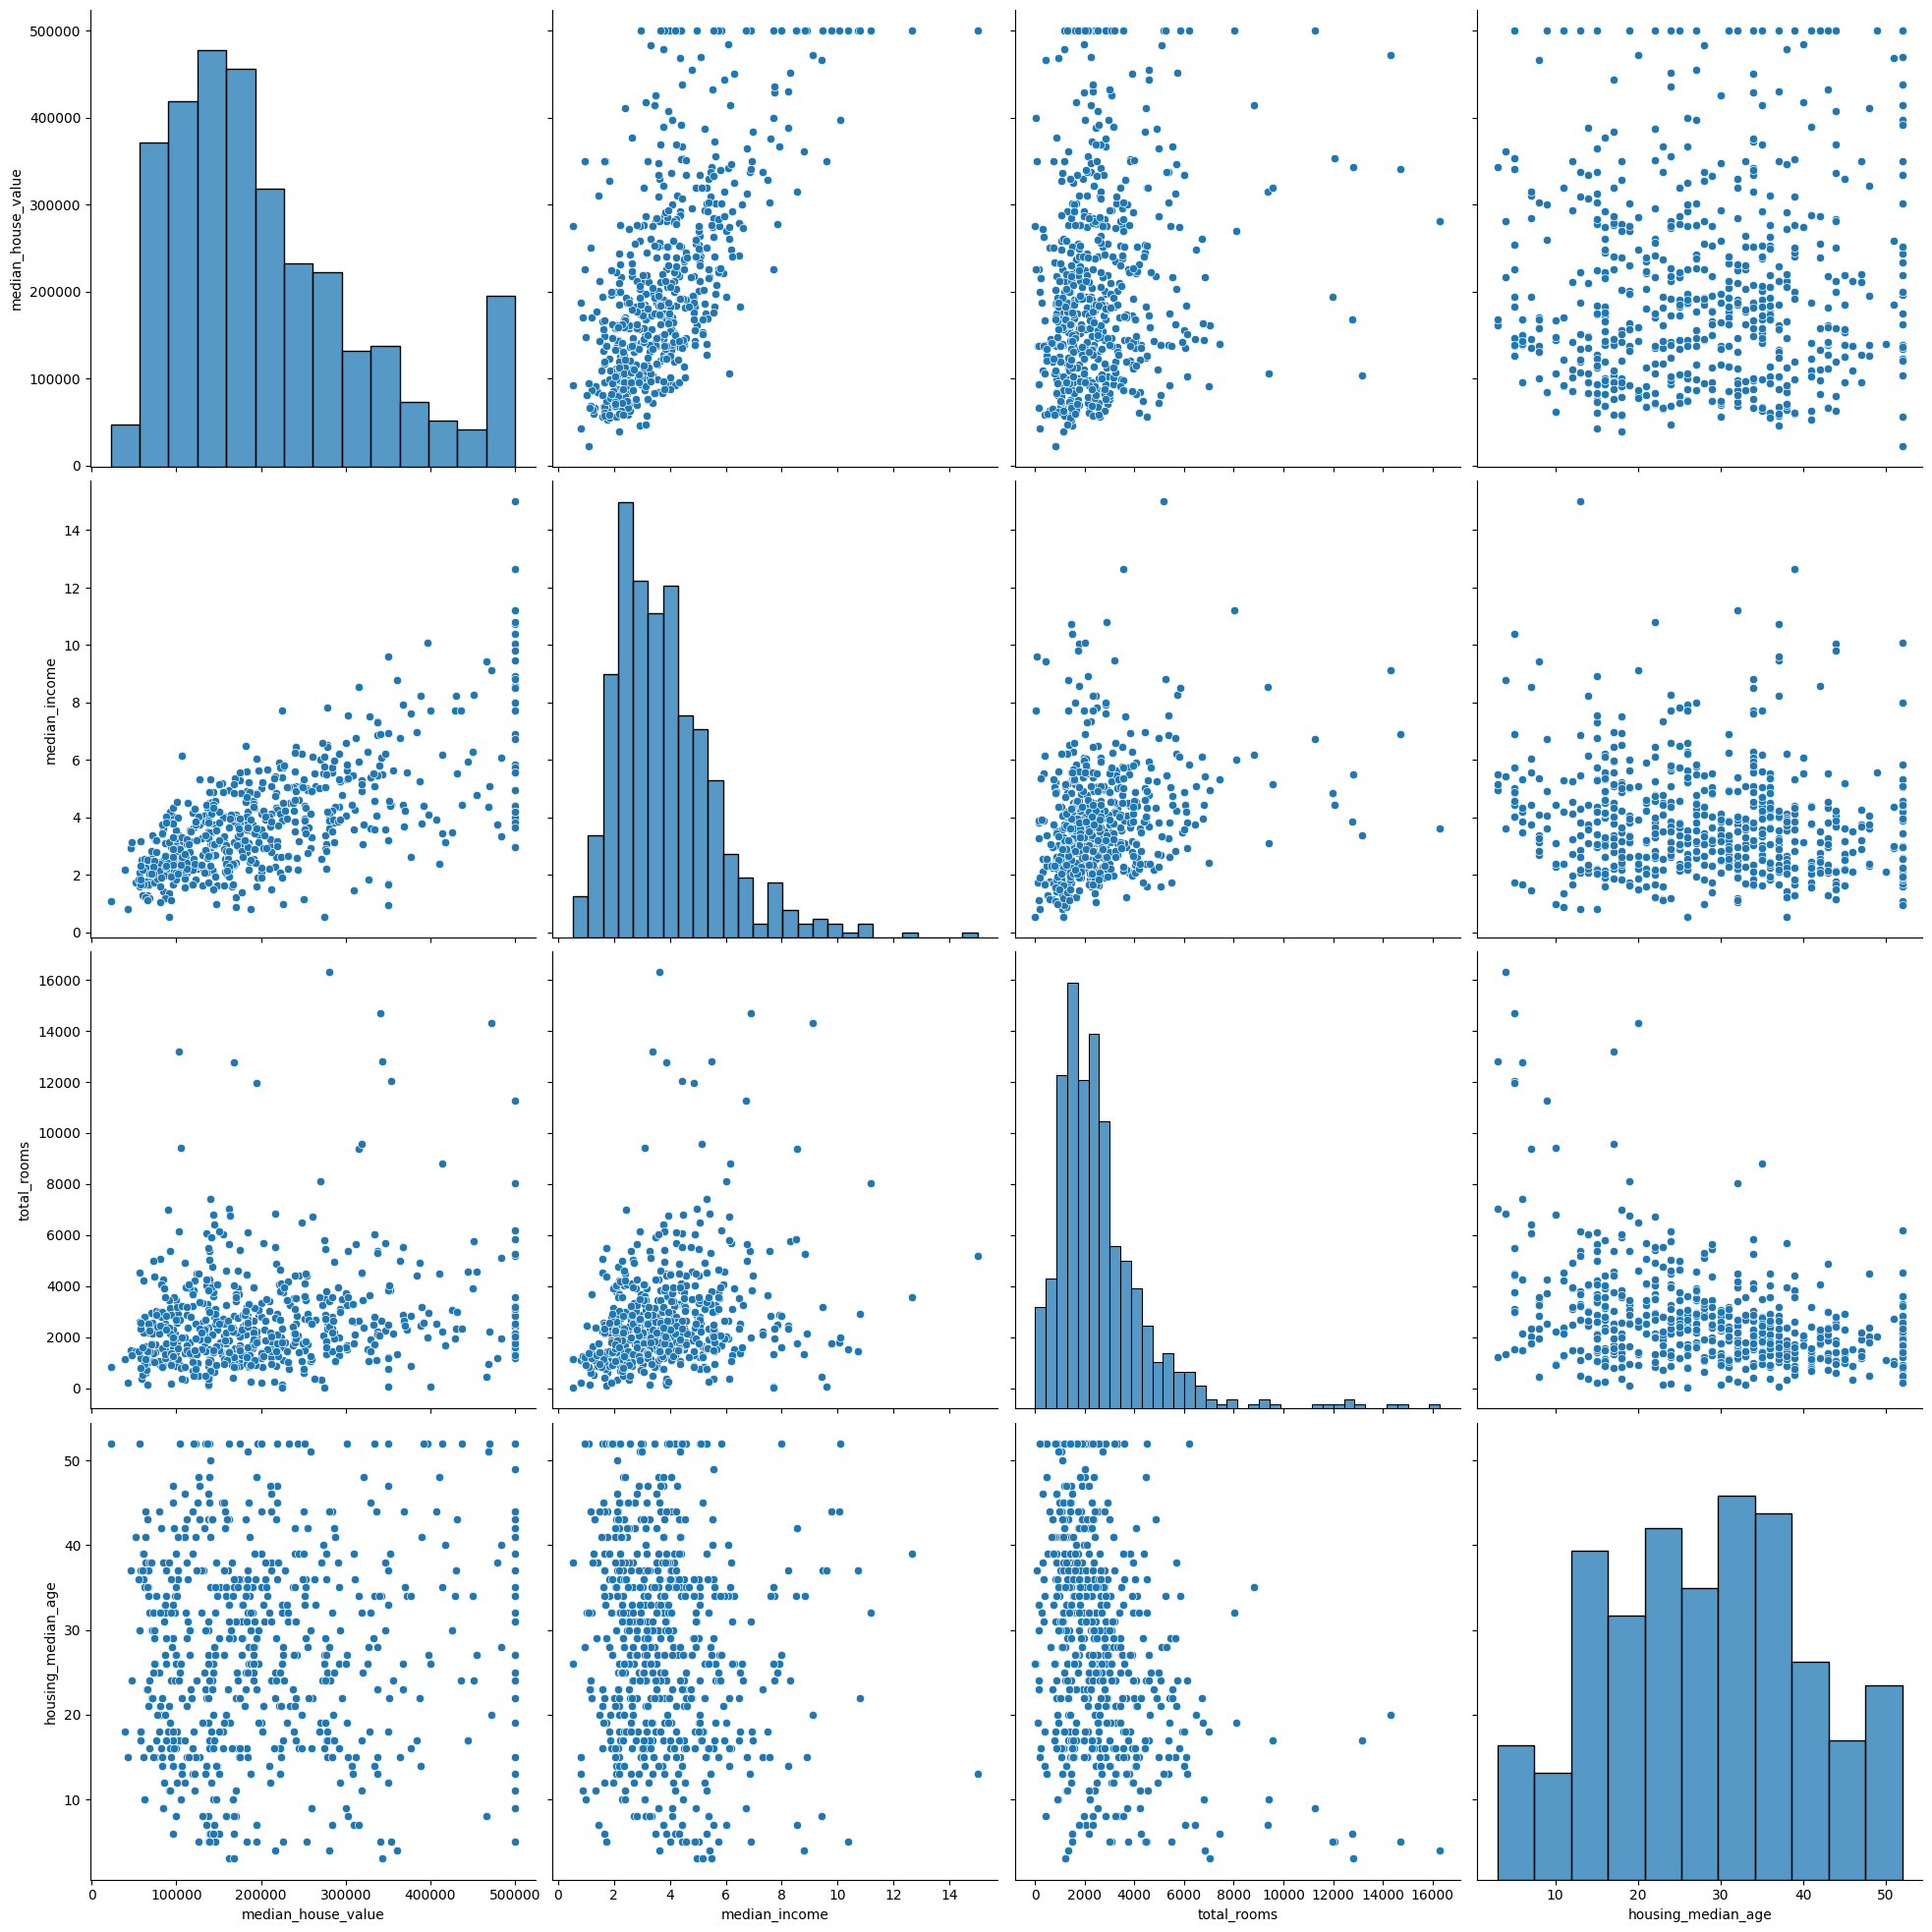

In [33]:
cols = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']
sns.pairplot(housing[cols], height=5)
plt.show()

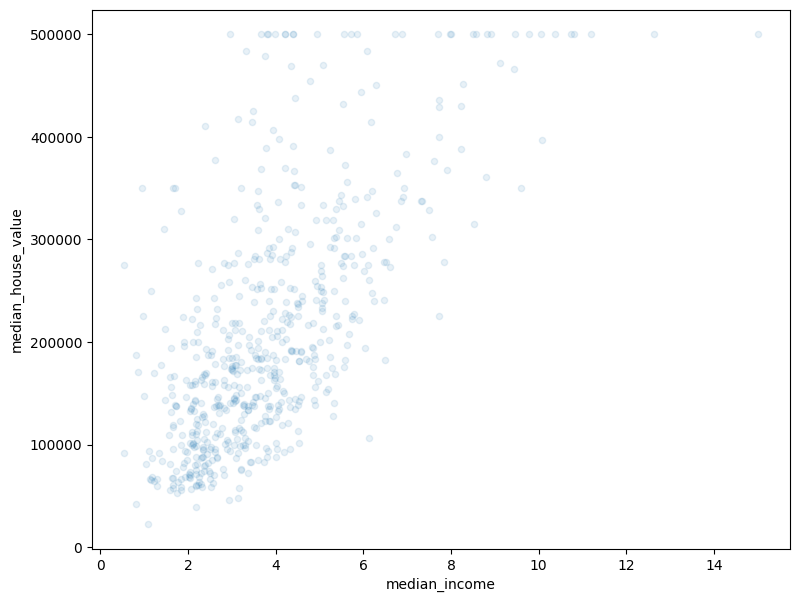

In [35]:
housing.plot(kind='scatter', x="median_income", y="median_house_value", alpha=0.1, figsize=(9,7))
plt.show()

In [36]:
housing.corrwith(housing['median_house_value']).sort_values(ascending=False)

,0
median_house_value,1.000000
median_income,0.671468
total_rooms,0.186604
households,0.108957
housing_median_age,0.100255
total_bedrooms,0.089968
population,0.015768
longitude,-0.031104
latitude,-0.153184


In [37]:
housing['rooms_per_household'] = housing['total_rooms']/housing['households']
housing['bedrooms_per_room'] = housing['total_rooms']/housing['total_rooms']
housing['population_per_household'] = housing['population']/housing['households']



In [38]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
280,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,5.504202,1.0,1.865546
785,-120.35,37.04,37.0,1495.0,292.0,858.0,275.0,2.9306,46300.0,5.436364,1.0,3.120000
2387,-117.30,34.05,6.0,2155.0,544.0,1039.0,391.0,1.6675,95800.0,5.511509,1.0,2.657289
2526,-118.08,33.77,26.0,2461.0,562.0,971.0,544.0,2.1944,87500.0,4.523897,1.0,1.784926
2341,-120.35,39.34,29.0,1986.0,474.0,337.0,100.0,4.0278,95800.0,19.860000,1.0,3.370000


In [39]:
housing.corrwith(housing['median_house_value']).sort_values(ascending=False)

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,0
median_house_value,1.000000
median_income,0.671468
total_rooms,0.186604
rooms_per_household,0.138281
households,0.108957
housing_median_age,0.100255
total_bedrooms,0.089968
population,0.015768
longitude,-0.031104
latitude,-0.153184


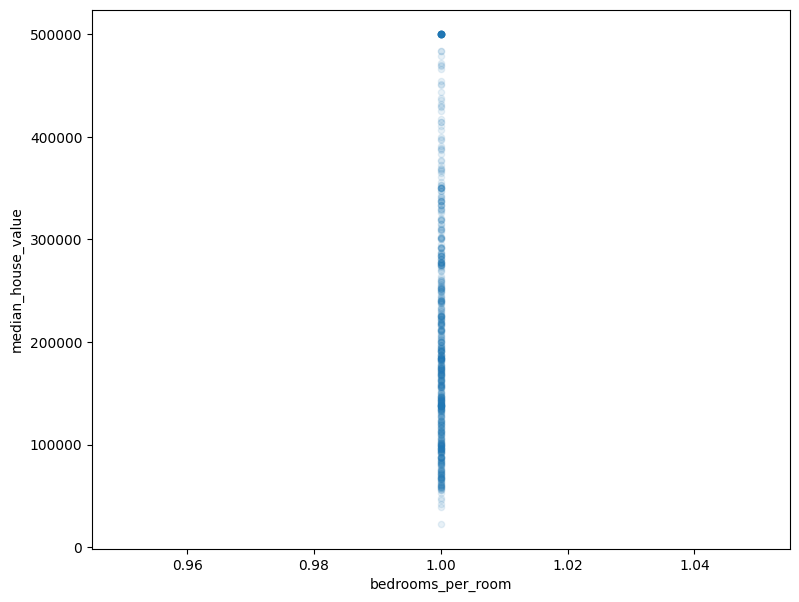

In [41]:
housing.plot(kind='scatter', x="bedrooms_per_room", y="median_house_value", alpha=0.1, figsize=(9,7))
plt.show()